# Notebook 03

## Phase 3 — Analyse, Visualise & Report

### Exploratory Data Analysis + Insights

This notebook focuses on visually exploring the data and generating insights.  
Use the final processed features from Notebook 02 (`features.csv` or the output DataFrame).

---

## Tasks — EDA

> **Create notebook:** `03_eda.ipynb`

- [ ] **Histograms / KDE:** plot distributions of at least 3 numerical features  
      - Describe each shape: skewed, symmetric, or other  
- [ ] **Grouped boxplots:** compare the target across at least 2 categories  
- [ ] **Correlation heatmap:** show top 10 features most correlated with the target  
- [ ] **Scatter plot:** plot a key relationship, use color or size for a third variable  
- [ ] **Groupby summary:** compute mean target by a category — identify highest and lowest groups  
- [ ] **Write 1-paragraph insight** for each chart or table: explain what it tells about the data  

---

> **Tip:** Add a comment or Markdown cell explaining every decision.  
> This notebook builds directly on Notebook 02.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/cleaned/features.csv")

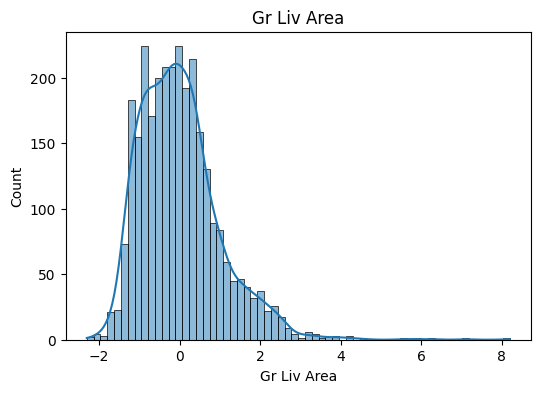

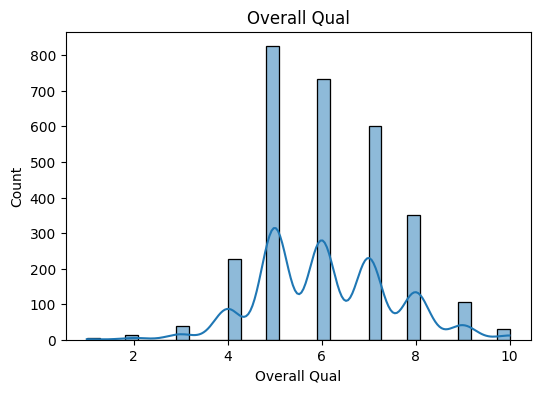

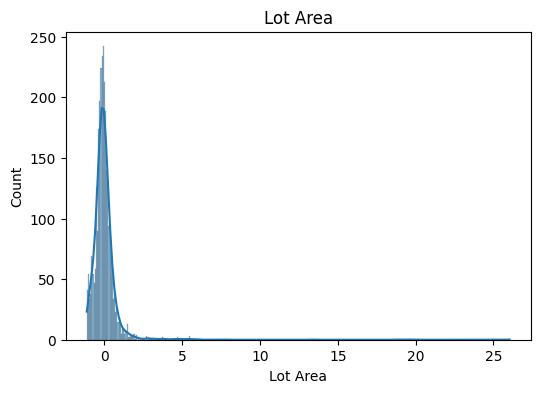

In [3]:
columns = ["Gr Liv Area", "Overall Qual", "Lot Area"] # select columns to plot

for col in columns:
    plt.figure(figsize=(6, 4)) # set figure size
    sns.histplot(df[col], kde=True) # plot distribution
    plt.title(col) # add title
    plt.savefig(f"figures/{col.replace(' ', '_').lower()}_distribution.png", dpi=150, bbox_inches="tight") # save the plot
    plt.show() # display plot
# • Histograms / KDE: plot distributions of at least 3 numerical features — describe the shape (skewed? symmetric?)

## Distribution Observations
1. **Gr Liv Area**: slightly right-skewed, most data centered near zero
2. **Overall Qual**: discrete and multimodal, most homes rated 5 or 6
3. **Lot Area**: highly right-skewed, few very large lots pulling the tail

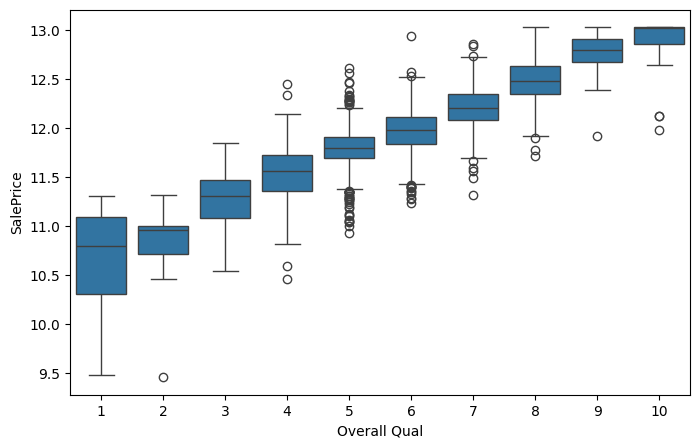

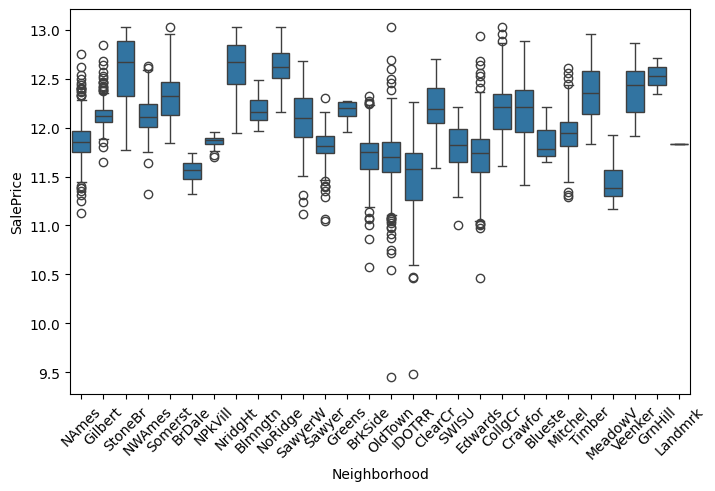

In [4]:
plt.figure(figsize=(8, 5)) # set figure size
sns.boxplot(x="Overall Qual", y="SalePrice", data=df)  # compare SalePrice by Overall Qual
plt.savefig("figures/overall_qual_saleprice_boxplot.png", dpi=150, bbox_inches="tight") # save the plot
plt.show()  # show the plot

plt.figure(figsize=(8, 5)) # set figure size
sns.boxplot(x="Neighborhood", y="SalePrice", data=df)  # compare SalePrice by Neighborhood
plt.xticks(rotation=45)  # rotate labels for clarity
plt.savefig("figures/neighborhood_saleprice_boxplot.png", dpi=150, bbox_inches="tight") # save the plot
plt.show()  # show the plot
# • Grouped boxplots: compare the target across at least 2 categories

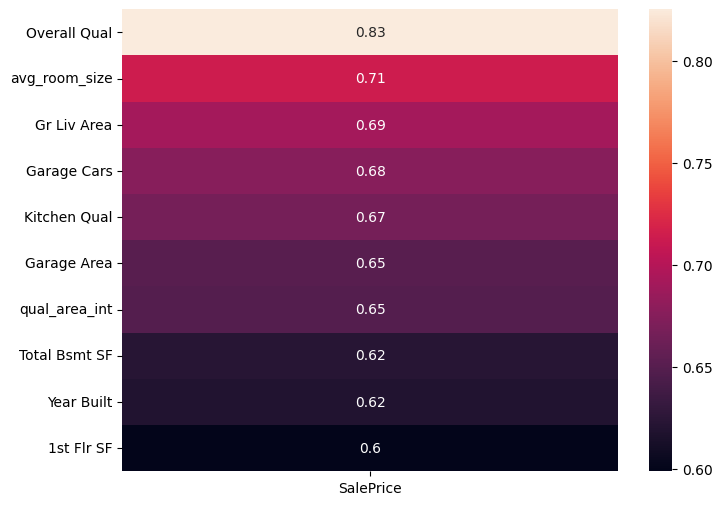

In [5]:
corr = df.corr(numeric_only=True)["SalePrice"].drop("SalePrice")  # compute correlation with target
corr = corr.sort_values(ascending=False)  # sort from strongest to weakest
top10 = corr.head(10)  # select top 10 features

plt.figure(figsize=(8, 6)) # set figure size
sns.heatmap(top10.to_frame(), annot=True)  # draw heatmap with values
plt.savefig("figures/correlation_heatmap.png", dpi=150, bbox_inches="tight") # save the plot
plt.show() # display the plot
# • Correlation heatmap: show the top 10 features most correlated with the target

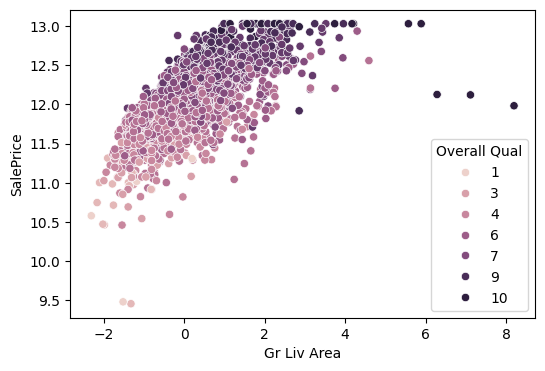

In [6]:
plt.figure(figsize=(6, 4)) # set figure size
sns.scatterplot(x="Gr Liv Area", y="SalePrice", hue="Overall Qual", data=df) # scatter plot with colour for Overall Qual
plt.savefig("figures/gr_liv_area_saleprice_scatter.png", dpi=150, bbox_inches="tight") # save the plot
plt.show() # display the plot
# • Scatter plot: plot a key relationship with colour or size for a third variable

In [7]:
df.groupby("House Style")["SalePrice"].mean().sort_values(ascending=False) # compare average SalePrice by House Style

House Style
2.5Fin    12.189310
2Story    12.162286
2.5Unf    12.013034
1Story    12.001359
SLvl      11.997490
SFoyer    11.847808
1.5Fin    11.783533
1.5Unf    11.586558
Name: SalePrice, dtype: float64

## Groupby Observations
**Highest:** 2.5Fin — **Lowest:** 1.5Unf

# Data Analysis Insights

### 1. Histograms / KDE
Gr Liv Area and Lot Area are right-skewed, so most values are small and only a few are large. Overall Qual is mostly around 5 and 6, so most homes have average quality.
![Correlation Heatmap](figures/gr_liv_area_distribution.png)
![Correlation Heatmap](figures/overall_qual_distribution.png)
![Correlation Heatmap](figures/lot_area_distribution.png)

### 2. Grouped Boxplots
Higher Overall Qual usually means higher SalePrice. Neighborhood also changes the price a lot, so location matters.
![Correlation Heatmap](figures/overall_qual_saleprice_boxplot.png)
![Correlation Heatmap](figures/neighborhood_saleprice_boxplot.png)

### 3. Correlation Heatmap
Overall Qual has the strongest link with SalePrice, followed by Gr Liv Area. This shows that quality and size are important for price.
![Correlation Heatmap](figures/correlation_heatmap.png)

### 4. Scatter Plot
Gr Liv Area and SalePrice have a positive relationship. Bigger homes usually cost more. Higher quality homes also tend to have higher prices.
![Correlation Heatmap](figures/gr_liv_area_saleprice_scatter.png)

### 5. Groupby Summary
2.5Fin and 2Story have the highest average SalePrice, while 1.5Unf has the lowest. This shows that house style affects price.

• Write a 1-paragraph insight for each chart (what does it tell us?)